In [1]:
import torch
from torch.nn import CrossEntropyLoss
import json
import timm

from NAS.HybridNAS import HybridNAS
from NAS.CompressedViT import CompressedViT
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim import AdamW
from FirstFineTuning.FineTuneUtils import EarlyStopping, train_model, eval_loop, check_top5_accuracy
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
with open("D:\\Tesi\\NAS\\best_architecture.json", "r") as f:
    search_dict = json.load(f)

num_classes = 200
model = timm.create_model("vit_small_patch16_224", pretrained=False, num_classes=num_classes)
checkpoint = torch.load("D:\\Tesi\\FirstFineTuning\\best_model.pth")
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [3]:
pruned_model = HybridNAS.apply_pruning(state=search_dict, model=model)
comp_model = CompressedViT(search_dict, pruned_model)
comp_model.to(device)

CompressedViT(
  (patch_embed): PatchEmbed(
    (patch_embed): Conv2d(3, 371, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_enc): PositionalEncoding()
  (blocks): Sequential(
    (0): EncoderBlock(
      (mhsa): MultiHeadSelfAttention(
        (qkv): Linear(in_features=371, out_features=570, bias=True)
        (proj): Linear(in_features=186, out_features=371, bias=True)
      )
      (layerNorm1): LayerNorm((371,), eps=1e-06, elementwise_affine=True)
      (layerNorm2): LayerNorm((371,), eps=1e-06, elementwise_affine=True)
      (fc1): Linear(in_features=371, out_features=1536, bias=True)
      (fc2): Linear(in_features=1536, out_features=371, bias=True)
      (mlp): Sequential(
        (0): Linear(in_features=371, out_features=1536, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=1536, out_features=371, bias=True)
      )
    )
    (1): EncoderBlock(
      (mhsa): MultiHeadSelfAttention(
        (qkv): Linear(in_features=371, out_features=955, bias

In [4]:
batch_size = 128
N_epochs = 16
lr = 2e-5
weight_decay = 0.05

In [5]:
data_config = timm.data.resolve_model_data_config(model)
imagenet_mean, imagenet_std = data_config["mean"], data_config["std"]

val_transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(mean=imagenet_mean, std=imagenet_std)])

train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
        transforms.ToTensor(), transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ]
)

batch_size = 128

val_set = ImageFolder(root="D:\\Tesi\\Sets\\Set1\\val", transform=val_transform)
train_set = ImageFolder(root="D:\\Tesi\\Sets\\Set1\\train", transform=train_transform)

In [6]:
#creazione dei dataset e dataloader
classes = train_set.classes

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

optim = AdamW(comp_model.parameters(), weight_decay=weight_decay)
scheduler = CosineAnnealingLR(optim, T_max=N_epochs, eta_min=1e-7)
loss_fn = CrossEntropyLoss()
early_stopping = EarlyStopping(path="D:\\Tesi\\SecondFineTuning", patience=3, min_delta=0.01)

In [7]:
print(eval_loop(comp_model, val_loader, loss_fn, device)[1])

0.5758581606217616


In [8]:
train_loss, val_loss, accuracy = train_model(comp_model, N_epochs, optimizer=optim, device=device,
                                             train_dataloader=train_loader, loss_fn=loss_fn,
                                             early_stopping=early_stopping, val_dataloader=val_loader,
                                             scheduler=scheduler)

Epoch 1: 100%|██████████| 3666/3666 [13:57<00:00,  4.38it/s]


Train_loss: 2.3811
Val loss: 2.0777	Accuracy: 0.4667



Epoch 2: 100%|██████████| 3666/3666 [13:55<00:00,  4.39it/s]


Train_loss: 1.9598
Val loss: 1.8791	Accuracy: 0.5115



Epoch 3: 100%|██████████| 3666/3666 [13:55<00:00,  4.39it/s]


...

Train_loss: 1.6796
Val loss: 1.7166	Accuracy: 0.5468



Epoch 5: 100%|██████████| 3666/3666 [14:20<00:00,  4.26it/s]


Train_loss: 1.5773
Val loss: 1.6320	Accuracy: 0.5672



Epoch 6:  12%|█▏        | 438/3666 [01:44<12:51,  4.19it/s]


KeyboardInterrupt: 

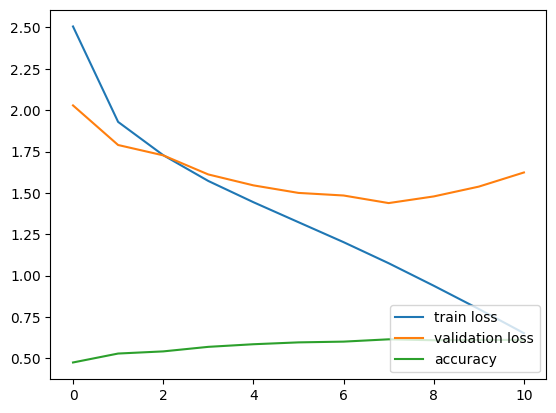

In [9]:
plt.plot(train_loss, label="train loss")
plt.plot(val_loss, label="validation loss")
plt.plot(accuracy, label='accuracy')
plt.legend(loc='lower right')
plt.show()

In [3]:
checkpoint = torch.load("D:\\Tesi\\SecondFineTuning\\best_model.pth")
comp_model.load_state_dict(checkpoint['model_state_dict'])
_, _, y_true, y_pred = eval_loop(comp_model, val_loader, loss_fn, device, classes, report=True)
print(f"Top5 accuracy: {check_top5_accuracy(model, val_loader, device):.2f}%")

<All keys matched successfully>